<img alt="Finance Scenarios" src="/assets/images/projects/financescenarios/banner.png" width="100%" />


# Finance Scenarios -- 4. Portfolio Analysis

> How would this mix actually have done in the past, what really drives it, and how does it
> compare with another mix?

Three steps, all on history rather than simulated scenarios:

- a *backtest*: the same portfolio engine run on what prices actually did;
- *factor exposure*: how much the mix moves with the stock market and with well-known investment styles, measured
  with the [Fama-French factors](https://doi.org/10.1016/j.jfineco.2014.10.010) from
  [Ken French's data library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html);
- a *benchmark*: two portfolios compared head to head.

## Backtesting on history

`scenarios.history(portfolio="balanced_60_40")` fetches what the 60/40's holdings actually did, month by month, as a
`ScenarioSet` with a single "future". Everything that works on a simulated run works on it, so
`Portfolio.from_preset` and `compute` are the same calls as in notebook 3.

In [1]:
import polars as pl

from financescenarios import Portfolio, Scenarios

pl.Config.set_tbl_width_chars(200)  # wide enough that long factor names are not wrapped

scenarios = Scenarios.from_profiles(settings="default", factor_set="us_only")
history = scenarios.history(portfolio="balanced_60_40")
print(f"{history.factor_names}: {history.dates[0]} to {history.dates[-1]} ({len(history.dates)} months)")

portfolio = Portfolio.from_preset(history, preset="balanced_60_40")
values = portfolio.compute(initial_value=100.0, rebalance_every=12)
values.describe()

['us_broad', 'united_states_long_rate']: 2000-01-01 to 2026-10-01 (322 months)


factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""portfolio""","""Portfolio""","""portfolio""","""annualized""",null,0.070988,0.070988,0.070988
"""us_broad_value""","""US Broad Value""","""holding""","""annualized""",null,0.073121,0.073121,0.073121
"""united_states_long_rate_value""","""United States Long Rate Value""","""holding""","""annualized""",null,0.067569,0.067569,0.067569


On a single path there is no spread of scenarios, so `risk_metrics()` reads the real yearly return
(`cagr_percentiles`, all equal) and the real worst dip (*maximum drawdown*).

In [2]:
risk = portfolio.risk_metrics()
print(f"yearly return:     {risk.cagr_percentiles['50']:.2%}")
print(f"worst dip:         {risk.max_drawdown_percentiles['50']:.1%}")
print(f"yearly volatility: {risk.annualized_volatility:.1%}")

yearly return:     7.10%
worst dip:         -28.3%
yearly volatility: 8.8%


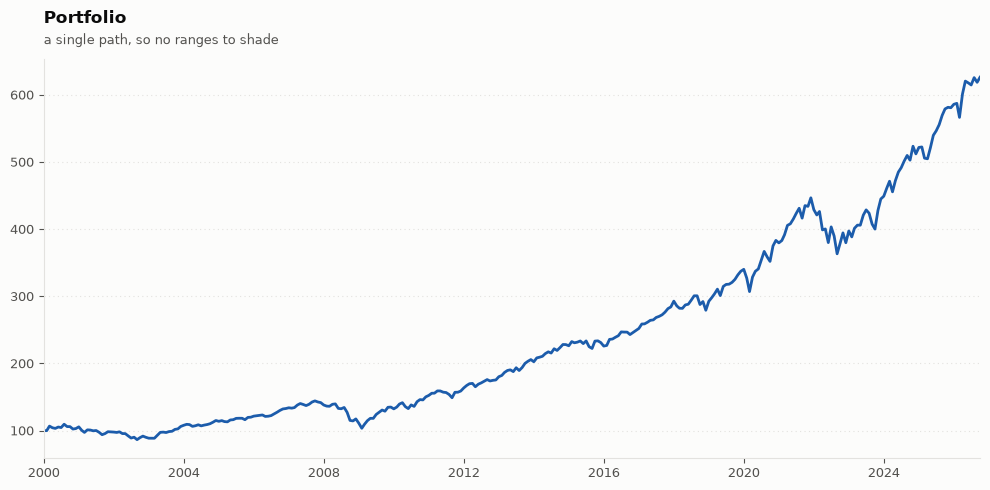

In [3]:
values.plot(levels=True)

## Factor exposure

> Is the mix as diversified as it looks? This measures how much of its ups and downs come from the
> stock market as a whole and from well-known styles.

`factor_exposure()` regresses the backtest's monthly returns on the five Fama-French factors
(*beta, R-squared*): `Mkt-RF` is the stock market, `SMB` small versus large
companies, `HML` cheap versus expensive, `RMW` profitable versus not, `CMA` conservative versus aggressive investment.
`r_squared` is the share of the ups and downs these factors explain. It only makes sense on history, since simulated
scenarios have no real dates to line up with.

In [4]:
portfolio.factor_exposure()

portfolio,Mkt-RF,SMB,HML,RMW,CMA,alpha,r_squared,observations,from,to
str,f64,f64,f64,f64,f64,f64,f64,i64,date,date
"""60/40 Balanced""",0.53988,-0.071436,-0.041963,0.120064,-0.01677,0.000802,0.865422,319,2000-01-01,2026-10-01


A market beta below 0.6 means the mix moved less than its 60% in stocks suggests, because over this window US
Treasuries tended to rise when stocks fell; the rest of the movement is the bonds' own interest-rate moves.

As a check with a known answer: 100% in the stock market should have a market beta of about 1.0 and an R-squared close
to 1. `model="three_factor"` uses only the first three factors.

In [5]:
stocks_only = portfolio.compute({"us_broad": 1.0}, initial_value=100.0)
portfolio.factor_exposure(stocks_only, model="three_factor").select("Mkt-RF", "SMB", "HML", "r_squared")

Mkt-RF,SMB,HML,r_squared
f64,f64,f64,f64
0.991439,-0.164092,0.025129,0.992029


## Comparing two portfolios

> How closely do two mixes move together, how different are their holdings, and which earned more?

`portfolio.benchmark(values, other_values, ...)` compares two computed portfolios over the dates they share:
*tracking error* (how far apart their returns wander each year), correlation, beta to the benchmark, *active share*
(how much of the holdings differ) and the difference in yearly return and Sharpe ratio. Here the 60/40 against 100%
stocks; the 60/40's own weights come from its preset.

In [6]:
relative = portfolio.benchmark(values, stocks_only, benchmark_weights={"us_broad": 1.0})

print(f"tracking error:     {relative.tracking_error:.2%}")
print(f"correlation:        {relative.correlation:.3f}")
print(f"beta to stocks:     {relative.beta:.3f}")
print(f"active share:       {relative.active_share:.0%}")
print(f"yearly return gap:  {relative.relative_cagr:+.2%}")
print(f"Sharpe ratio gap:   {relative.relative_sharpe_ratio:+.3f}")

tracking error:     6.86%
correlation:        0.972
beta to stocks:     0.566
active share:       40%
yearly return gap:  -1.41%
Sharpe ratio gap:   +0.208


The 60/40 earned less per year than stocks alone but with a better Sharpe ratio (return per unit of risk). Two
portfolios may also come from different `history()` calls with different date ranges; the comparison uses the dates
they have in common.